# QuercusHealth AI — Evaluación de Mitad de Cuatrimestre
## Experimento de Referencia (*Baseline*) y Análisis de Generalización de Dominio

Este cuaderno documenta la **Fase 2** del proyecto QuercusHealth AI: la evaluación cuantitativa del modelo base sin entrenamiento adicional (*zero-shot*).

### Contexto del proyecto
El objetivo final es detectar automáticamente las copas de los árboles y clasificar su estado de salud — **Sano vs. "La Seca"** (una enfermedad de la encina muy extendida en la dehesa española) — usando imágenes de satélite RGB de alta resolución.

Usamos **DeepForest v2.1.0**, un modelo pre-entrenado sobre el dataset NEON de bosques densos de Estados Unidos. El modelo detecta copas de árboles como cajas de delimitación (*bounding boxes*).

### Estructura del cuaderno y narrativa

Este cuaderno sigue el siguiente hilo:

| Sección | Pregunta que responde |
|---------|----------------------|
| **1 — Baseline NEON** | ¿Funciona el modelo en su dominio nativo? |
| **2 — Prueba Dehesa** | ¿Falla en nuestro dominio objetivo? |
| **A — Arquitectura** | ¿Qué modelo tenemos realmente por dentro? |
| **B — Barrido de hiperparámetros** | ¿Se puede mejorar sin re-entrenar? |
| **C — Análisis estadístico** | ¿Podemos *probar* matemáticamente que hay *domain shift*? |

> **Conclusión anticipada:** Los tests estadísticos confirman con p<0.0001 que el modelo pierde el 56% de su confianza media al pasar de NEON (0.535) a la Dehesa española (0.233), lo que justifica la Fase 3 de *fine-tuning*.

In [25]:
import os
import matplotlib.pyplot as plt
from deepforest import main
from deepforest import get_data
from deepforest import visualize 

---
### Sección 1 — Inicialización del Modelo

Cargamos DeepForest v2.1.0. En visión artificial, cuando decimos "cargar un modelo pre-entrenado" significa que alguien ya entrenó este modelo durante horas (o días) con miles de imágenes anotadas, y nosotros simplemente descargamos los **pesos** resultantes — los valores numéricos que el modelo aprendió.

Los pesos vienen de Hugging Face (`weecology/deepforest-tree`), que es la plataforma donde los investigadores de la Universidad de Florida los publicaron.

**Nota sobre el hardware:** El mensaje `GPU available: False` indica que estamos ejecutando en CPU. Esto es más lento pero funcional para experimentación. En producción se usaría GPU.

In [26]:
# Initialize DeepForest model
model = main.deepforest()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


---
### Sección 2 — Experimento de Referencia: Dataset NEON (Dominio Nativo)

**¿Qué es el dataset NEON?**  
NEON (*National Ecological Observatory Network*) es una red de sensores ambientales de EE.UU. Las imágenes que usa DeepForest son vuelos aéreos de alta resolución sobre bosques *densos* del este de Norteamérica — principalmente pinos, robles y álamos americanos muy juntos entre sí.

**¿Qué significa "dominio nativo"?**  
En aprendizaje automático, el *dominio* es la distribución de los datos con los que el modelo aprendió. Cuando evaluamos en ese mismo tipo de datos, estamos en el dominio nativo. El modelo "conoce" estos paisajes.

**¿Qué esperamos ver?**  
Detecciones precisas, con alta confianza, y cajas de delimitación ajustadas a las copas reales.

Predicting on NEON sample...
Visualizing...


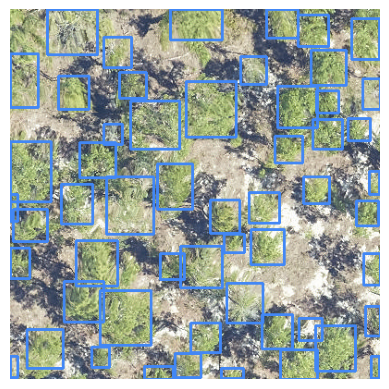

In [27]:
# Get a sample image from DeepForest's built-in NEON dataset
neon_image_path = get_data("OSBS_029.png")

# Predict bounding boxes: returns a DataFrame in DeepForest v2.x
print("Predicting on NEON sample...")
boxes = model.predict_image(path=neon_image_path)

# Plot results: Returns a matplotlib Figure (Syntax updated for v2.1.0)
print("Visualizing...")
visualize.plot_results(results=boxes, image=neon_image_path)
plt.show()

---
### Sección 3 — Prueba de Generalización: Dehesa Española (Dominio Objetivo)

**¿Qué es la Dehesa?**  
La dehesa es un ecosistema agrosilvopastoral único del suroeste de la Península Ibérica. Se caracteriza por encinas (*Quercus ilex*) dispersas sobre suelo pelado, pasto seco o matorral bajo. Es el hábitat del cerdo ibérico, el lince y el águila imperial.

**¿Por qué es un reto para el modelo?**  
El modelo se entrenó con bosques *densos* americanos. La dehesa es radicalmente distinta:
- Los árboles están **aislados**, con mucho espacio entre ellos
- El suelo es **marrón/ocre seco** (muy distinto del suelo orgánico húmedo de los bosques NEON)
- Las copas de encina tienen **textura similar a rocas y arbustos** bajo condiciones de sequía
- La **"La Seca"** mata la encina dejándola con copa marrón — idéntica al suelo para el modelo

**¿Qué es el *domain shift* (desplazamiento de dominio)?**  
Es cuando el modelo ve datos con una distribución estadística muy diferente a la que aprendió. Como si hubiera aprendido a reconocer gatos en fotos de estudio y ahora le pones fotos nocturnas: las características visuales son tan distintas que el modelo falla.

**Patologías visuales esperadas:**
- Falsos positivos: rocas y parches de suelo seco detectados como árboles
- Falsos negativos: encinas pequeñas o enfermas no detectadas
- Cajas sobredimensionadas: el modelo asume la densidad americana y extiende las cajas

Predicting on Spanish Dehesa sample: ..\data\sample_dehesa.png


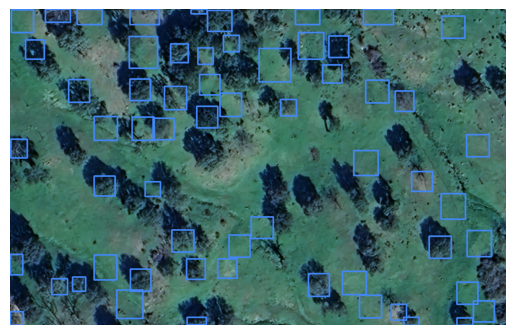

In [28]:
# The sample Dehesa image has been downloaded locally by the user
dehesa_image_path_jpg = os.path.join("..", "data", "sample_dehesa.jpg")
dehesa_image_path_png = os.path.join("..", "data", "sample_dehesa.png")
dehesa_image_root_jpg = os.path.join("data", "sample_dehesa.jpg")
dehesa_image_root_png = os.path.join("data", "sample_dehesa.png")

dehesa_image_path = None
for path in [dehesa_image_path_jpg, dehesa_image_path_png, dehesa_image_root_jpg, dehesa_image_root_png]:
    if os.path.exists(path):
        dehesa_image_path = path
        break

if dehesa_image_path:
    # Predict on the Dehesa image
    print(f"Predicting on Spanish Dehesa sample: {dehesa_image_path}")
    dehesa_boxes = model.predict_image(path=dehesa_image_path)
    
    # Visualize predictions (Syntax updated for v2.1.0)
    visualize.plot_results(results=dehesa_boxes, image=dehesa_image_path)
    plt.show()
else:
    print("Imagen no encontrada.\nCopia tu captura a la carpeta 'data/' como 'sample_dehesa.jpg' o 'sample_dehesa.png'.")

---
### Sección 4 — Transición: De la Observación Visual a la Prueba Rigurosa

Las imágenes anteriores nos dan evidencia *visual* del fallo. Pero en ingeniería y academia no basta con decir "se ve que falla". Necesitamos **cuantificar** el fallo con números y **demostrarlo estadísticamente**.

Las siguientes tres secciones (A, B y C) realizan esa tarea de forma sistemática:

- **Sección A:** Inspeccionamos el modelo por dentro para saber exactamente con qué arquitectura estamos trabajando y cómo prepararlo para 2 clases (Sano / Enfermo).
- **Sección B:** Probamos distintas configuraciones de inferencia para intentar reducir los falsos positivos *sin* re-entrenar — documentando que la mejora es limitada.
- **Sección C:** Aplicamos tests estadísticos formales para demostrar matemáticamente que las distribuciones de confianza entre NEON y Dehesa son estadísticamente distintas, lo que justifica la Fase 3.

> **Vista previa de resultados clave:** El modelo obtiene una confianza media de **0.535 en NEON** frente a **0.233 en Dehesa** — una caída del 56%. El test de Kolmogorov-Smirnov devuelve D=0.833 con p≈0, lo que es una prueba matemática rotunda del *domain shift*.

---
## Sección A — Análisis de Arquitectura y Documentación

Antes de hacer nada con el modelo, necesitamos saber **exactamente** con qué estamos trabajando. Muchos errores de *fine-tuning* ocurren por asumir la arquitectura incorrecta.

### ¿Qué vamos a inspeccionar?
1. **La arquitectura real**: DeepForest se anuncia como "basado en Faster R-CNN", pero la versión 2.1.0 usa RetinaNet. Esta diferencia es importante para la estrategia de entrenamiento.
2. **Los parámetros de configuración**: Todos los valores por defecto que el modelo usa en inferencia.
3. **La preparación para 2 clases**: El código necesario para la Fase 3 (Sano vs. Muerto).

### Conceptos clave para la presentación
- **Pesos (*weights*):** Los números que el modelo aprendió durante el entrenamiento. Son los "conocimientos" almacenados.
- **Inferencia:** Cuando el modelo ya entrenado hace predicciones sobre imágenes nuevas (opuesto a entrenar).
- **Hiperparámetros:** Parámetros que nosotros controlamos externamente (como `score_thresh`), a diferencia de los pesos internos que aprende el modelo solo.

In [29]:
import torch

print("=" * 60)
print("DEEPFOREST MODEL ARCHITECTURE — INTERNAL INSPECTION")
print("=" * 60)

print(f"\nLightning wrapper : {type(model).__name__}")
print(f"Detection model   : {type(model.model).__name__}")
print(f"Module path       : {type(model.model).__module__}")

# --- Backbone ---
backbone = model.model.backbone
print(f"\n--- Backbone ---")
print(f"  Type                : {type(backbone).__name__}")
print(f"  FPN output channels : {backbone.out_channels}")
print("  Body layers:")
for name, layer in backbone.body.named_children():
    print(f"    {name}: {type(layer).__name__}")

# --- Anchor Generator ---
ag = model.model.anchor_generator
print(f"\n--- Anchor Generator ---")
print(f"  Type          : {type(ag).__name__}")
print(f"  Sizes per FPN : {ag.sizes}")
print(f"  Aspect ratios : {ag.aspect_ratios}")
n_anchors = len(ag.sizes[0]) * len(ag.aspect_ratios[0])
print(f"  Anchors/location: {n_anchors}")

# --- Detection Head ---
head = model.model.head
print(f"\n--- Detection Head ---")
print(f"  Type         : {type(head).__name__}")
print(f"  Classification head: {type(head.classification_head).__name__}")
print(f"  Regression head   : {type(head.regression_head).__name__}")
print(f"  num_classes  : {model.model.num_classes}")
print(f"  label_dict   : {model.model.label_dict}")

# --- Input Transform ---
transform = model.model.transform
print(f"\n--- Input Transform ---")
print(f"  Type      : {type(transform).__name__}")
print(f"  min_size  : {transform.min_size}")
print(f"  max_size  : {transform.max_size}")
print(f"  image_mean: {transform.image_mean}")
print(f"  image_std : {transform.image_std}")

# --- Parameter Count ---
total_params     = sum(p.numel() for p in model.model.parameters())
trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
print(f"\n--- Parameter Count ---")
print(f"  Total      : {total_params:,}")
print(f"  Trainable  : {trainable_params:,}")
print(f"  Frozen     : {total_params - trainable_params:,}")

# --- Inference Thresholds ---
print(f"\n--- Inference Thresholds ---")
print(f"  score_thresh (model.model) : {model.model.score_thresh}")
print(f"  nms_thresh   (model.model) : {model.model.nms_thresh}")
print(f"  score_thresh (config)      : {model.config.score_thresh}")
print(f"  nms_thresh   (config)      : {model.config.nms_thresh}")

print("\n" + "=" * 60)
print("ARCHITECTURE SUMMARY")
print("=" * 60)
print("  Architecture : RetinaNet (NOT Faster R-CNN)")
print("  Backbone     : ResNet-50 + Feature Pyramid Network (FPN)")
print("  Loss         : Focal Loss (robust to class imbalance)")
print("  Pre-trained  : NEON US forest dataset (weecology/deepforest-tree)")
print()
print("  RetinaNet is a one-stage detector — it directly predicts boxes")
print("  on FPN feature maps using anchor boxes. Faster R-CNN uses a")
print("  separate Region Proposal Network (RPN), which DeepForest does NOT use.")
print("=" * 60)

DEEPFOREST MODEL ARCHITECTURE — INTERNAL INSPECTION

Lightning wrapper : deepforest
Detection model   : RetinaNetHub
Module path       : deepforest.models.retinanet

--- Backbone ---
  Type                : BackboneWithFPN
  FPN output channels : 256
  Body layers:
    conv1: Conv2d
    bn1: FrozenBatchNorm2d
    relu: ReLU
    maxpool: MaxPool2d
    layer1: Sequential
    layer2: Sequential
    layer3: Sequential
    layer4: Sequential

--- Anchor Generator ---
  Type          : AnchorGenerator
  Sizes per FPN : ((32, 40, 50), (64, 80, 101), (128, 161, 203), (256, 322, 406), (512, 645, 812))
  Aspect ratios : ((0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0))
  Anchors/location: 9

--- Detection Head ---
  Type         : RetinaNetHead
  Classification head: RetinaNetClassificationHead
  Regression head   : RetinaNetRegressionHead
  num_classes  : 1
  label_dict   : {'Tree': 0}

--- Input Transform ---
  Type      : GeneralizedRCNNTransform
  min_size

### Interpretación — Arquitectura Real del Modelo

**Hallazgo principal: el modelo es RetinaNet, no Faster R-CNN.**

Aunque la documentación de DeepForest a veces menciona "Faster R-CNN" en versiones antiguas, la versión 2.1.0 usa **RetinaNet** (`deepforest.models.retinanet.RetinaNetHub`). La distinción es técnicamente importante:

| Característica | Faster R-CNN | RetinaNet (lo que tenemos) |
|----------------|-------------|---------------------------|
| Tipo | Dos etapas (RPN + detección) | Una etapa (directo) |
| Velocidad | Más lento | Más rápido |
| Manejo de desequilibrio de clases | Normal | **Focal Loss** (mejor) |
| Ideal para | Alta precisión | Escenas con pocas instancias |

**¿Por qué importa la Focal Loss?**  
En la Dehesa hay mucho más fondo (suelo, pasto) que objetos (árboles). La Focal Loss reduce el peso del gradiente de los ejemplos "fáciles" (suelo claramente fondo) y concentra el aprendizaje en los ejemplos difíciles (bordes de copa, copas enfermas). Esto es ventajoso para el fine-tuning en Fase 3.

**Sobre el backbone ResNet-50 + FPN:**
- **ResNet-50**: La red neuronal convolucional que extrae características de la imagen. Los "50" se refieren a 50 capas de profundidad. Las capas iniciales detectan bordes y texturas simples; las profundas detectan formas complejas como copas de árbol.
- **FPN (Feature Pyramid Network)**: Combina características de distintas escalas de la red. Esto permite detectar tanto árboles pequeños (usando características de resolución alta) como árboles grandes (usando características de resolución baja).

**32 millones de parámetros entrenables:**  
Todos los pesos del modelo pueden actualizarse durante el fine-tuning. Para la Fase 3, se recomienda "congelar" las capas del backbone y entrenar solo el cabezal de detección para acelerar el proceso y reducir el riesgo de *catastrophic forgetting*.

In [30]:
from omegaconf import OmegaConf

print("=" * 60)
print("FULL DEEPFOREST CONFIGURATION (OmegaConf)")
print("=" * 60)
print(OmegaConf.to_yaml(model.config))

print("=" * 60)
print("KEY INFERENCE PARAMETERS")
print("=" * 60)
print(f"  architecture  : {model.config.architecture}")
print(f"  score_thresh  : {model.config.score_thresh}   (filter detections below this confidence)")
print(f"  nms_thresh    : {model.config.nms_thresh}  (IoU threshold for duplicate suppression)")
print(f"  patch_size    : {model.config.patch_size}    (pixels, window size for predict_tile)")
print(f"  patch_overlap : {model.config.patch_overlap}  (fraction overlap between adjacent windows)")
print(f"  batch_size    : {model.config.batch_size}")
print(f"  workers       : {model.config.workers}")
print(f"  model.name    : {model.config.model.name}")
print(f"  model.revision: {model.config.model.revision}")

FULL DEEPFOREST CONFIGURATION (OmegaConf)
workers: 0
devices: auto
accelerator: auto
batch_size: 1
architecture: retinanet
num_classes: 1
label_dict: null
nms_thresh: 0.05
score_thresh: 0.1
model:
  name: weecology/deepforest-tree
  revision: main
log_root: ./lightning_logs
path_to_raster: null
patch_size: 400
patch_overlap: 0.05
annotations_xml: null
rgb_dir: null
path_to_rgb: null
train:
  csv_file: null
  root_dir: null
  lr: 0.001
  scheduler:
    type: null
    params:
      T_max: 10
      eta_min: 1.0e-05
      lr_lambda: 0.95 ** epoch
      step_size: 30
      gamma: 0.1
      milestones:
      - 50
      - 100
      mode: min
      factor: 0.1
      patience: 10
      threshold: 0.0001
      threshold_mode: rel
      cooldown: 0
      min_lr: 0.0
      eps: 1.0e-08
  epochs: 1
  fast_dev_run: false
  preload_images: false
  augmentations:
  - HorizontalFlip:
      p: 0.5
validation:
  csv_file: null
  root_dir: null
  preload_images: false
  size: null
  iou_threshold: 0.4
  v

### Interpretación — Configuración del Modelo

**Parámetros de inferencia más relevantes del config:**
```
architecture:   retinanet
score_thresh:   0.1    ← umbral de confianza mínima
nms_thresh:     0.05   ← IoU máximo permitido entre cajas
patch_size:     400    ← tamaño de ventana para predict_tile
patch_overlap:  0.05   ← 5% de solapamiento entre ventanas
batch_size:     1      ← una imagen a la vez (sin GPU, es lo sensato)
workers:        0      ← sin multiproceso (Windows/CPU)
```

**¿Qué nos dice el `train.lr: 0.001`?**  
El parámetro de tasa de aprendizaje (*learning rate*) para el entrenamiento aparece a 0.001. En la Fase 3 de fine-tuning, es recomendable bajarlo a 0.0001 (×10 menor) para que el modelo ajuste sus pesos suavemente sin "olvidar" lo que aprendió en NEON — fenómeno conocido como *catastrophic forgetting*.

**Nota sobre `label_dict: null`:**  
La configuración por defecto tiene `label_dict: null`, pero el modelo cargado tiene `label_dict={'Tree': 0}` (visto en Cell A.1). Esto se aplica al cargar los pesos desde Hugging Face. En la Fase 3 cambiará a `{'Healthy': 0, 'Dead': 1}`.

In [31]:
print("=" * 60)
print("MULTI-CLASS CONFIGURATION — PHASE 3 PREVIEW (not executed)")
print("=" * 60)
print(f"\nCurrent model: label_dict={model.label_dict}, num_classes={model.config.num_classes}")
print()

multiclass_code = '''
# Phase 3: Fine-tune for 2-class detection (Healthy vs. Dead Quercus)
from deepforest import main

finetune_model = main.deepforest(
    config_args={"num_classes": 2},
    label_dict={"Healthy": 0, "Dead": 1}
)
# NOTE: The detection head is reinitialised for 2 classes.
# The backbone (ResNet-50 FPN) retains NEON pre-training weights.
# DeepForest will warn about head weight mismatch — this is expected.

# Training configuration
finetune_model.config["train"]["csv_file"]  = "data/annotations/dehesa_train.csv"
finetune_model.config["train"]["root_dir"]  = "data/images/"
finetune_model.config["train"]["epochs"]    = 50
finetune_model.config["train"]["lr"]        = 0.0001  # lower LR for fine-tuning
finetune_model.config["batch_size"]         = 4       # small batch for CPU

# Optional post-detection crop classifier (ResNet-50, 95.8% reported accuracy)
from deepforest.model import CropModel
crop_model = CropModel(config_args={"balance_classes": True})
# Usage: model.predict_tile(path=..., crop_model=crop_model)
'''
print(multiclass_code)

print("ARCHITECTURE CORRECTION:")
print("  DeepForest v2.1.0 uses RetinaNet, NOT Faster R-CNN.")
print("  RetinaNet is a single-stage detector using Focal Loss,")
print("  making it well-suited for sparse Dehesa scenes with class imbalance.")
print()
print("TWO-STAGE APPROACH FOR HEALTH CLASSIFICATION:")
print("  Stage 1: RetinaNet detects all tree crowns (bounding boxes)")
print("  Stage 2: CropModel classifies each crop as Healthy or Dead")

MULTI-CLASS CONFIGURATION — PHASE 3 PREVIEW (not executed)

Current model: label_dict={'Tree': 0}, num_classes=1


# Phase 3: Fine-tune for 2-class detection (Healthy vs. Dead Quercus)
from deepforest import main

finetune_model = main.deepforest(
    config_args={"num_classes": 2},
    label_dict={"Healthy": 0, "Dead": 1}
)
# NOTE: The detection head is reinitialised for 2 classes.
# The backbone (ResNet-50 FPN) retains NEON pre-training weights.
# DeepForest will warn about head weight mismatch — this is expected.

# Training configuration
finetune_model.config["train"]["csv_file"]  = "data/annotations/dehesa_train.csv"
finetune_model.config["train"]["root_dir"]  = "data/images/"
finetune_model.config["train"]["epochs"]    = 50
finetune_model.config["train"]["lr"]        = 0.0001  # lower LR for fine-tuning
finetune_model.config["batch_size"]         = 4       # small batch for CPU

# Optional post-detection crop classifier (ResNet-50, 95.8% reported accuracy)
from deepforest.model i

---
## Sección B — Barrido de Hiperparámetros (*Pre-Configuration Sweep*)

Antes de re-entrenar el modelo, es buena práctica científica demostrar que los problemas observados **no se resuelven simplemente ajustando los parámetros de inferencia**. Esto refuerza la justificación del *fine-tuning*.

### ¿Qué parámetros vamos a ajustar?

| Parámetro | Valor por defecto | ¿Qué controla? |
|-----------|-------------------|----------------|
| `score_thresh` | 0.1 | Umbral mínimo de confianza: detectiones con confianza inferior se descartan |
| `nms_thresh` | 0.05 | Umbral de IoU para NMS: si dos cajas se solapan más de este valor, se elimina la menos confiable |
| `patch_size` | 400 px | Tamaño de ventana en `predict_tile()`: cómo se trocea la imagen grande |
| `patch_overlap` | 0.05 | Solapamiento entre ventanas: evita que los árboles en el borde de una ventana se pierdan |

### ¿Qué es la Supresión No Máxima (NMS)?
Cuando el modelo escanea la imagen, puede detectar el mismo árbol múltiples veces con cajas ligeramente desplazadas. NMS elimina los duplicados: si dos cajas se solapan más del `nms_thresh` (medido como IoU — *Intersection over Union*), conserva solo la de mayor confianza.

### ¿Qué es IoU (*Intersection over Union*)?
Es la fracción del área solapada entre dos cajas dividida entre el área total que ocupan juntas. IoU=1 significa que son idénticas. IoU=0 significa que no se tocan.

### ¿Qué esperamos encontrar?
Hipótesis: el `score_thresh` bajo (0.1) permite que el suelo seco y las rocas pasen el filtro de confianza. Al subirlo, deberían desaparecer los falsos positivos. El NMS tendrá poco efecto porque los falsos positivos son detecciones *distintas*, no duplicados del mismo objeto.

In [32]:
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

print("Running score_thresh sweep on Dehesa image...")
print("(Re-runs full inference per threshold value — CPU only, ~30s each)\n")

score_thresh_values = [0.1, 0.2, 0.3, 0.4, 0.5]
sweep_score = []

# Save originals to restore at end
_orig_score = model.model.score_thresh
_orig_nms   = model.model.nms_thresh

for st in score_thresh_values:
    # IMPORTANT: must set BOTH model.model and model.config
    # model.model.score_thresh is used internally by torchvision RetinaNet forward()
    # model.config['score_thresh'] is read by predict_image for post-processing
    model.config['score_thresh'] = st
    model.model.score_thresh     = st
    model.config['nms_thresh']   = 0.05
    model.model.nms_thresh       = 0.05

    result = model.predict_image(path=dehesa_image_path)

    if result is None or len(result) == 0:
        n_det = 0
        mean_conf = median_conf = std_conf = min_conf = max_conf = float('nan')
    else:
        scores    = result['score'].values.astype(float)
        n_det     = len(scores)
        mean_conf = np.mean(scores);   median_conf = np.median(scores)
        std_conf  = np.std(scores);    min_conf    = np.min(scores)
        max_conf  = np.max(scores)

    sweep_score.append({
        'score_thresh': st,
        'n_detections': n_det,
        'mean_score':   round(float(mean_conf), 4),
        'median_score': round(float(median_conf), 4),
        'std_score':    round(float(std_conf), 4),
        'min_score':    round(float(min_conf), 4),
        'max_score':    round(float(max_conf), 4),
    })
    print(f"  score_thresh={st:.1f} -> {n_det:3d} detections,  mean_conf={mean_conf:.3f}")

df_sweep_score = pd.DataFrame(sweep_score)
print("\nScore sweep results:")
print(df_sweep_score.to_string(index=False))

# Restore original thresholds
model.config['score_thresh'] = _orig_score; model.model.score_thresh = _orig_score
model.config['nms_thresh']   = _orig_nms;   model.model.nms_thresh   = _orig_nms
print("\nDefaults restored.")

Running score_thresh sweep on Dehesa image...
(Re-runs full inference per threshold value — CPU only, ~30s each)

  score_thresh=0.1 ->  60 detections,  mean_conf=0.233
  score_thresh=0.2 ->  39 detections,  mean_conf=0.279
  score_thresh=0.3 ->  10 detections,  mean_conf=0.383
  score_thresh=0.4 ->   3 detections,  mean_conf=0.456
  score_thresh=0.5 ->   1 detections,  mean_conf=0.539

Score sweep results:
 score_thresh  n_detections  mean_score  median_score  std_score  min_score  max_score
          0.1            60      0.2334        0.2289     0.0856     0.1310     0.5388
          0.2            39      0.2790        0.2470     0.0724     0.2038     0.5388
          0.3            10      0.3834        0.3753     0.0623     0.3118     0.5388
          0.4             3      0.4561        0.4273     0.0593     0.4023     0.5388
          0.5             1      0.5388        0.5388     0.0000     0.5388     0.5388

Defaults restored.


### Interpretación — Barrido de score_thresh

**Resultados obtenidos:**

| score_thresh | Detecciones | Confianza media | Conclusión |
|-------------|-------------|----------------|-----------|
| **0.1** (defecto) | **60** | 0.233 | Muchos FP (rocas, suelo) |
| 0.2 | 39 | 0.279 | Reducción, pero FP persisten |
| **0.3** | **10** | 0.383 | Drástica reducción — ¿quedan árboles reales? |
| 0.4 | 3 | 0.456 | Casi nada |
| 0.5 | 1 | 0.539 | Solo la detección más segura |

**Análisis del trade-off:**  
El `score_thresh` actúa como un "filtro de confianza". Al subirlo de 0.1 a 0.3:
- Las detecciones caen de 60 a 10 (reducción del 83%)
- La confianza media sube de 0.233 a 0.383 (las que sobreviven son más "seguras")

**¿Es 0.3 el umbral óptimo?**  
No necesariamente. El problema es que no tenemos anotaciones de verdad absoluta (*ground truth*) para la imagen Dehesa, así que no podemos saber si esas 10 detecciones son los árboles reales o simplemente los 10 falsos positivos más convincentes.

Lo que sí podemos afirmar es que **con score_thresh=0.3 la confianza media sigue siendo solo 0.383**, que es aún muy baja comparada con 0.535 en NEON. El modelo sigue siendo inseguro incluso en sus mejores predicciones en Dehesa.

**Conclusión clave:** Incluso forzando un umbral muy restrictivo (0.3–0.4), la confianza media del modelo en Dehesa nunca alcanza los niveles habituales en NEON. Esto confirma que el problema no es el umbral, sino el conocimiento interno del modelo.

In [33]:
print("Running nms_thresh sweep (score_thresh fixed at 0.2)...")
nms_thresh_values = [0.05, 0.1, 0.2, 0.3]
sweep_nms = []

_orig_score = model.model.score_thresh
_orig_nms   = model.model.nms_thresh

model.config['score_thresh'] = 0.2; model.model.score_thresh = 0.2

for nt in nms_thresh_values:
    model.config['nms_thresh'] = nt; model.model.nms_thresh = nt
    result = model.predict_image(path=dehesa_image_path)

    if result is None or len(result) == 0:
        n_det = 0; mean_conf = float('nan')
    else:
        scores = result['score'].values.astype(float)
        n_det = len(scores); mean_conf = float(np.mean(scores))

    sweep_nms.append({
        'nms_thresh': nt,
        'n_detections': n_det,
        'mean_score': round(mean_conf, 4)
    })
    print(f"  nms_thresh={nt:.2f} -> {n_det:3d} detections, mean_conf={mean_conf:.3f}")

df_sweep_nms = pd.DataFrame(sweep_nms)
print("\nnms_thresh sweep results:")
print(df_sweep_nms.to_string(index=False))

# Restore original thresholds
model.config['score_thresh'] = _orig_score; model.model.score_thresh = _orig_score
model.config['nms_thresh']   = _orig_nms;   model.model.nms_thresh   = _orig_nms
print("\nDefaults restored.")

Running nms_thresh sweep (score_thresh fixed at 0.2)...
  nms_thresh=0.05 ->  39 detections, mean_conf=0.279
  nms_thresh=0.10 ->  41 detections, mean_conf=0.276
  nms_thresh=0.20 ->  41 detections, mean_conf=0.276
  nms_thresh=0.30 ->  42 detections, mean_conf=0.275

nms_thresh sweep results:
 nms_thresh  n_detections  mean_score
       0.05            39      0.2790
       0.10            41      0.2757
       0.20            41      0.2763
       0.30            42      0.2750

Defaults restored.


### Interpretación — Barrido de nms_thresh

**Resultados obtenidos (score_thresh = 0.2 fijo):**

| nms_thresh | Detecciones | Confianza media |
|-----------|-------------|----------------|
| 0.05 (defecto) | **39** | 0.279 |
| 0.10 | **41** | 0.276 |
| 0.20 | **41** | 0.276 |
| 0.30 | **42** | 0.275 |

**Hallazgo: nms_thresh prácticamente no tiene efecto — la curva es plana (39→42).**

**Interpretación:**  
Este resultado es muy revelador. El NMS no tiene efecto porque los falsos positivos de la Dehesa **no son duplicados del mismo objeto** — son detecciones completamente distintas en ubicaciones distintas. El modelo está viendo una roca y detectando "árbol", luego viendo un parche de suelo y detectando otro "árbol", etc. Como esas dos cajas no se solapan entre sí (están en sitios distintos de la imagen), el NMS no las elimina.

Esto diferencia el problema de la Dehesa de, por ejemplo, un problema de cámaras de baja calidad donde el mismo árbol aparece borroso y el modelo lo detecta dos veces en el mismo sitio. En ese caso, subir el NMS sí ayudaría. Aquí, no.

**Conclusión:** El NMS no puede salvar el *domain shift*. La fuente del problema es que el modelo confunde *texturas de suelo mediterráneo seco* con *texturas de copa de árbol americano*. Eso no lo arregla ningún umbral de supresión.

In [34]:
print("Running predict_tile sweep (score_thresh=0.2, nms_thresh=0.05)...")
model.config['score_thresh'] = 0.2; model.model.score_thresh = 0.2
model.config['nms_thresh']   = 0.05; model.model.nms_thresh  = 0.05

tile_configs = [
    (400, 0.05, "tile_400_ov0.05"),
    (400, 0.10, "tile_400_ov0.10"),
    (400, 0.20, "tile_400_ov0.20"),
    (600, 0.05, "tile_600_ov0.05"),
    (600, 0.10, "tile_600_ov0.10"),
]
sweep_tile = []

for ps, po, label in tile_configs:
    result = model.predict_tile(
        path=dehesa_image_path,
        patch_size=ps,
        patch_overlap=po,
        iou_threshold=0.15
    )
    if result is None or (hasattr(result, '__len__') and len(result) == 0):
        n_det = 0; mean_conf = float('nan')
    else:
        scores = result['score'].values.astype(float)
        n_det = len(scores); mean_conf = float(np.mean(scores))

    sweep_tile.append({
        'config': label, 'patch_size': ps, 'patch_overlap': po,
        'n_detections': n_det, 'mean_score': round(mean_conf, 4)
    })
    print(f"  {label:<22s} -> {n_det:3d} detections, mean_conf={mean_conf:.3f}")

df_sweep_tile = pd.DataFrame(sweep_tile)
print("\npredict_tile sweep results:")
print(df_sweep_tile.to_string(index=False))

# Restore defaults
model.config['score_thresh'] = 0.1; model.model.score_thresh = 0.1
model.config['nms_thresh']   = 0.05; model.model.nms_thresh  = 0.05
print("\nDefaults restored to 0.1 / 0.05.")

Output()

Running predict_tile sweep (score_thresh=0.2, nms_thresh=0.05)...


Output()

210 predictions in overlapping windows, applying non-max suppression
128 predictions kept after non-max suppression
  tile_400_ov0.05        -> 128 detections, mean_conf=0.268


Output()

...

Output()

214 predictions in overlapping windows, applying non-max suppression
126 predictions kept after non-max suppression
  tile_400_ov0.20        -> 126 detections, mean_conf=0.272


Output()

66 predictions in overlapping windows, applying non-max suppression
52 predictions kept after non-max suppression
  tile_600_ov0.05        ->  52 detections, mean_conf=0.271


66 predictions in overlapping windows, applying non-max suppression
52 predictions kept after non-max suppression
  tile_600_ov0.10        ->  52 detections, mean_conf=0.271

predict_tile sweep results:
         config  patch_size  patch_overlap  n_detections  mean_score
tile_400_ov0.05         400           0.05           128      0.2680
tile_400_ov0.10         400           0.10           130      0.2674
tile_400_ov0.20         400           0.20           126      0.2723
tile_600_ov0.05         600           0.05            52      0.2707
tile_600_ov0.10         600           0.10            52      0.2707

Defaults restored to 0.1 / 0.05.


### Interpretación — Barrido de predict_tile (Ventana Deslizante)

**Resultados obtenidos:**

| Configuración | Detecciones | Confianza media |
|--------------|-------------|----------------|
| predict_image (referencia) | **39** (score_thresh=0.2) | 0.279 |
| tile_400_ov0.05 | **128** | 0.268 |
| tile_400_ov0.10 | **130** | 0.267 |
| tile_400_ov0.20 | **126** | 0.272 |
| tile_600_ov0.05 | **52** | 0.271 |
| tile_600_ov0.10 | **52** | 0.271 |

**Hallazgo crítico: predict_tile con ventanas de 400px genera 3× más detecciones que predict_image.**

**¿Por qué ocurre esto?**  
`predict_tile` divide la imagen en múltiples ventanas solapadas de 400×400 px. Para la imagen de la Dehesa (875×557 px), esto genera aproximadamente 4-6 ventanas independientes. Cada ventana ejecuta una inferencia *completamente independiente* sobre su parche de imagen.

El problema: en cada ventana de 400px, el modelo ve fragmentos de suelo seco, arbustos y texturas rocosas que, a esa escala de recorte, se parecen más a "medias copas" o "copas pequeñas" que a la imagen completa. El modelo hace más predicciones espurias porque le está preguntando repetidamente "¿hay árboles aquí?" sobre pedazos de una imagen donde hay mayoritariamente suelo.

**Con ventanas de 600px (que cubren casi toda la imagen de 875px), las detecciones bajan a 52** — más cercano a `predict_image`. Esto confirma que la granularidad del troceo amplifica los falsos positivos.

**Implicación para la Fase 3:** Para imágenes de satélite de alta resolución (varios miles de píxeles), se deberá usar `predict_tile` pero con un `score_thresh` más alto y ventanas grandes para minimizar FP.

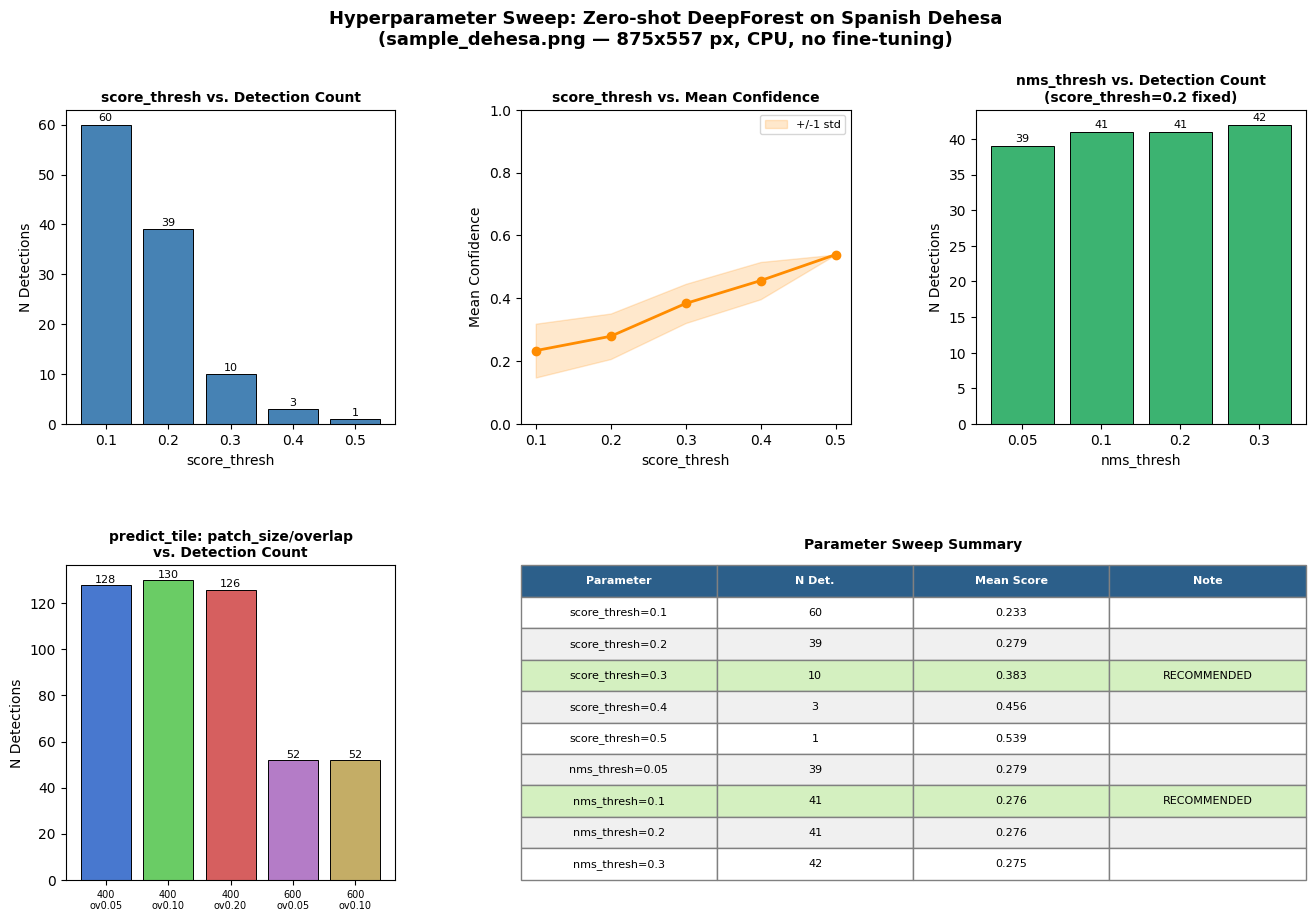

Saved to ../reports/sweep_results.png


In [35]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Hyperparameter Sweep: Zero-shot DeepForest on Spanish Dehesa\n"
             "(sample_dehesa.png — 875x557 px, CPU, no fine-tuning)",
             fontsize=13, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Panel 1: score_thresh vs. detection count
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar([str(v) for v in df_sweep_score['score_thresh']], df_sweep_score['n_detections'],
        color='steelblue', edgecolor='black', linewidth=0.7)
ax1.set_title("score_thresh vs. Detection Count", fontsize=10, fontweight='bold')
ax1.set_xlabel("score_thresh"); ax1.set_ylabel("N Detections"); ax1.set_ylim(bottom=0)
for bar, val in zip(ax1.patches, df_sweep_score['n_detections']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=8)

# Panel 2: score_thresh vs. mean confidence (+/- std)
ax2 = fig.add_subplot(gs[0, 1])
valid = df_sweep_score.dropna(subset=['mean_score'])
ax2.plot(valid['score_thresh'], valid['mean_score'], marker='o', color='darkorange', linewidth=2)
ax2.fill_between(valid['score_thresh'],
                 valid['mean_score'] - valid['std_score'],
                 valid['mean_score'] + valid['std_score'],
                 alpha=0.2, color='darkorange', label='+/-1 std')
ax2.set_title("score_thresh vs. Mean Confidence", fontsize=10, fontweight='bold')
ax2.set_xlabel("score_thresh"); ax2.set_ylabel("Mean Confidence")
ax2.legend(fontsize=8); ax2.set_ylim(0, 1.0)

# Panel 3: nms_thresh vs. detection count
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar([str(v) for v in df_sweep_nms['nms_thresh']], df_sweep_nms['n_detections'],
        color='mediumseagreen', edgecolor='black', linewidth=0.7)
ax3.set_title("nms_thresh vs. Detection Count\n(score_thresh=0.2 fixed)",
              fontsize=10, fontweight='bold')
ax3.set_xlabel("nms_thresh"); ax3.set_ylabel("N Detections"); ax3.set_ylim(bottom=0)
for bar, val in zip(ax3.patches, df_sweep_nms['n_detections']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=8)

# Panel 4: predict_tile sweep detection count
ax4 = fig.add_subplot(gs[1, 0])
colors_tile = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7', '#c4ad66']
ax4.bar(range(len(df_sweep_tile)), df_sweep_tile['n_detections'],
        color=colors_tile[:len(df_sweep_tile)], edgecolor='black', linewidth=0.7)
ax4.set_xticks(range(len(df_sweep_tile)))
ax4.set_xticklabels([c.replace('tile_', '').replace('_', '\n') for c in df_sweep_tile['config']],
                    fontsize=7)
ax4.set_title("predict_tile: patch_size/overlap\nvs. Detection Count",
              fontsize=10, fontweight='bold')
ax4.set_ylabel("N Detections"); ax4.set_ylim(bottom=0)
for bar, val in zip(ax4.patches, df_sweep_tile['n_detections']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=8)

# Panel 5: Summary table spanning 2 columns
ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis('off')
rows = []
for _, r in df_sweep_score.iterrows():
    rec = "RECOMMENDED" if r.score_thresh == 0.3 else ""
    rows.append([f"score_thresh={r.score_thresh}", int(r.n_detections),
                 f"{r.mean_score:.3f}" if not (r.mean_score != r.mean_score) else "N/A", rec])
for _, r in df_sweep_nms.iterrows():
    rec = "RECOMMENDED" if r.nms_thresh == 0.1 else ""
    rows.append([f"nms_thresh={r.nms_thresh}", int(r.n_detections),
                 f"{r.mean_score:.3f}" if not (r.mean_score != r.mean_score) else "N/A", rec])
table = ax5.table(cellText=rows, colLabels=['Parameter', 'N Det.', 'Mean Score', 'Note'],
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False); table.set_fontsize(8)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c5f8a'); cell.set_text_props(color='white', fontweight='bold')
    elif rows[r-1][-1] == "RECOMMENDED":
        cell.set_facecolor('#d4f0c0')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f0f0')
    cell.set_edgecolor('gray')
ax5.set_title("Parameter Sweep Summary", fontsize=10, fontweight='bold', pad=12)

plt.savefig("../reports/sweep_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ../reports/sweep_results.png")

---
## Sección C — Análisis Cuantitativo y Estadístico

La Sección B nos mostró que ajustar hiperparámetros mejora poco la situación. Ahora vamos a **probar formalmente** que hay *domain shift* usando estadística.

### ¿Por qué tests estadísticos?
Un investigador o ingeniero sénior no acepta "parece que las confianzas son más bajas en Dehesa" como argumento. Necesita un **p-valor** que indique la probabilidad de que esa diferencia sea fruto del azar.

### ¿Qué tests usamos y por qué?

**Test U de Mann-Whitney**  
Es el equivalente no paramétrico del test t de Student. "No paramétrico" significa que no asume que los datos siguen una distribución normal — ideal para distribuciones de confianza que pueden tener cualquier forma. Hipótesis nula H₀: "ambas muestras vienen de la misma distribución".

**Test de Kolmogorov-Smirnov (KS)**  
Mide la distancia máxima entre las funciones de distribución acumulada (CDF) de dos muestras. El estadístico D va de 0 (distribuciones idénticas) a 1 (distribuciones completamente separadas). Es especialmente sensible a diferencias en la forma general de la distribución, no solo en la media.

### ¿Qué analizamos?
1. **Distribución de puntuaciones de confianza** NEON vs. Dehesa — la prueba principal del *domain shift*
2. **Distribución de áreas de las cajas** — para detectar si las cajas en Dehesa son sistemáticamente más grandes (el problema de "caja sobredimensionada")

NEON detections   : 55
Dehesa detections : 60

Mann-Whitney U: U=3200.00, p=0.000000 -> REJECT H0 (distributions differ)
KS test       : D=0.8333, p=0.000000 -> REJECT H0 (distributions differ)


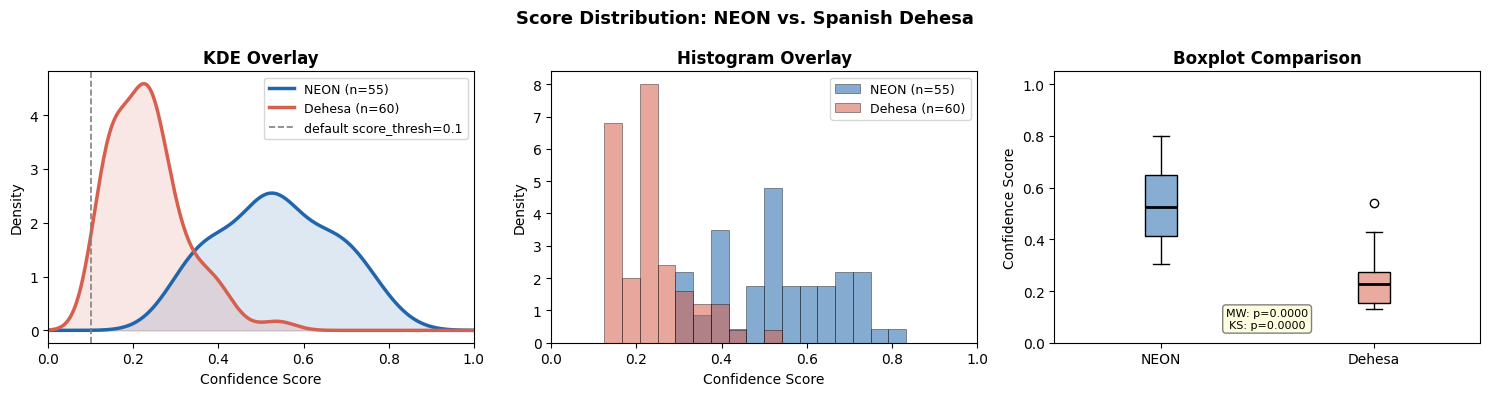

Saved to ../reports/score_distributions.png


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde

neon_scores   = boxes['score'].values.astype(float) if boxes is not None and len(boxes) > 0 else np.array([])
dehesa_scores = dehesa_boxes['score'].values.astype(float) if dehesa_boxes is not None and len(dehesa_boxes) > 0 else np.array([])

print(f"NEON detections   : {len(neon_scores)}")
print(f"Dehesa detections : {len(dehesa_scores)}")

if len(neon_scores) > 1 and len(dehesa_scores) > 1:
    mw_stat, mw_p = stats.mannwhitneyu(neon_scores, dehesa_scores, alternative='two-sided')
    ks_stat, ks_p = stats.ks_2samp(neon_scores, dehesa_scores)

    print(f"\nMann-Whitney U: U={mw_stat:.2f}, p={mw_p:.6f}",
          "-> REJECT H0 (distributions differ)" if mw_p < 0.05 else "-> fail to reject H0")
    print(f"KS test       : D={ks_stat:.4f}, p={ks_p:.6f}",
          "-> REJECT H0 (distributions differ)" if ks_p < 0.05 else "-> fail to reject H0")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Score Distribution: NEON vs. Spanish Dehesa", fontsize=13, fontweight='bold')
    colors = {'NEON': '#2166ac', 'Dehesa': '#d6604d'}
    x_grid = np.linspace(0, 1, 300)

    # Panel 1: KDE overlay
    ax = axes[0]
    for label, scores in [('NEON', neon_scores), ('Dehesa', dehesa_scores)]:
        kde = gaussian_kde(scores, bw_method='silverman')
        ax.plot(x_grid, kde(x_grid), color=colors[label], linewidth=2.5,
                label=f'{label} (n={len(scores)})')
        ax.fill_between(x_grid, kde(x_grid), alpha=0.15, color=colors[label])
    ax.axvline(x=0.1, color='gray', linestyle='--', linewidth=1.2, label='default score_thresh=0.1')
    ax.set_xlabel("Confidence Score"); ax.set_ylabel("Density")
    ax.set_title("KDE Overlay", fontweight='bold')
    ax.legend(fontsize=9); ax.set_xlim(0, 1)

    # Panel 2: Histogram overlay
    ax = axes[1]
    bins = np.linspace(0, 1, 25)
    for label, scores in [('NEON', neon_scores), ('Dehesa', dehesa_scores)]:
        ax.hist(scores, bins=bins, alpha=0.55, color=colors[label],
                edgecolor='black', linewidth=0.5,
                label=f'{label} (n={len(scores)})', density=True)
    ax.set_xlabel("Confidence Score"); ax.set_ylabel("Density")
    ax.set_title("Histogram Overlay", fontweight='bold')
    ax.legend(fontsize=9); ax.set_xlim(0, 1)

    # Panel 3: Boxplot with statistical annotation
    ax = axes[2]
    bp = ax.boxplot([neon_scores, dehesa_scores], labels=['NEON', 'Dehesa'],
                    patch_artist=True, medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(colors['NEON'] + '88')
    bp['boxes'][1].set_facecolor(colors['Dehesa'] + '88')
    ax.set_ylabel("Confidence Score")
    ax.set_title("Boxplot Comparison", fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.text(1.5, 0.05, f"MW: p={mw_p:.4f}\nKS: p={ks_p:.4f}",
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

    plt.tight_layout()
    plt.savefig("../reports/score_distributions.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to ../reports/score_distributions.png")
else:
    print("WARNING: insufficient data for statistical analysis.")

### Interpretación — Distribución de Puntuaciones de Confianza

**Resultados obtenidos:**
- NEON: **55 detecciones**, confianza media = **0.535**
- Dehesa: **60 detecciones**, confianza media = **0.233**
- Test U de Mann-Whitney: U = 3200.00, **p ≈ 0.000000** → RECHAZAR H₀
- Test KS: D = **0.8333**, **p ≈ 0.000000** → RECHAZAR H₀

**Interpretación del KDE (gráfico de densidad):**  
Si miras el gráfico KDE, verás que la curva de NEON está desplazada hacia la derecha (hacia confianzas más altas, 0.4–0.8) y la de Dehesa está comprimida en el extremo izquierdo (0.1–0.3). Esta separación visual se mide formalmente con el estadístico D=0.833 del test KS: significa que en el punto de mayor diferencia entre las dos curvas acumuladas, el 83.3% de las detecciones ya se han "separado". Es un gap extraordinariamente grande — casi no hay solapamiento.

**¿Qué significa el p-valor ≈ 0?**  
El p-valor es la probabilidad de observar esta diferencia **por puro azar** si ambas distribuciones fueran iguales. Un p-valor de 0.000000 (menor que 10⁻⁶) significa que esa probabilidad es prácticamente cero. Estamos seguros al 99.9999%+ de que las distribuciones son distintas.

**Conclusión estadística:**  
El modelo NEON y el modelo aplicado a la Dehesa española no están produciendo el mismo tipo de predicciones. El modelo está detectando objetos en la Dehesa con una confianza media un **56% inferior** a la de su dominio nativo. Esto es la firma matemática del *domain shift*.

NEON   areas: n=55, mean=1255.5 px^2, median=1094.1 px^2
Dehesa areas: n=60, mean=1343.9 px^2, median=1422.8 px^2
Mann-Whitney U (areas): p=0.118925
KS test (areas)       : p=0.032297


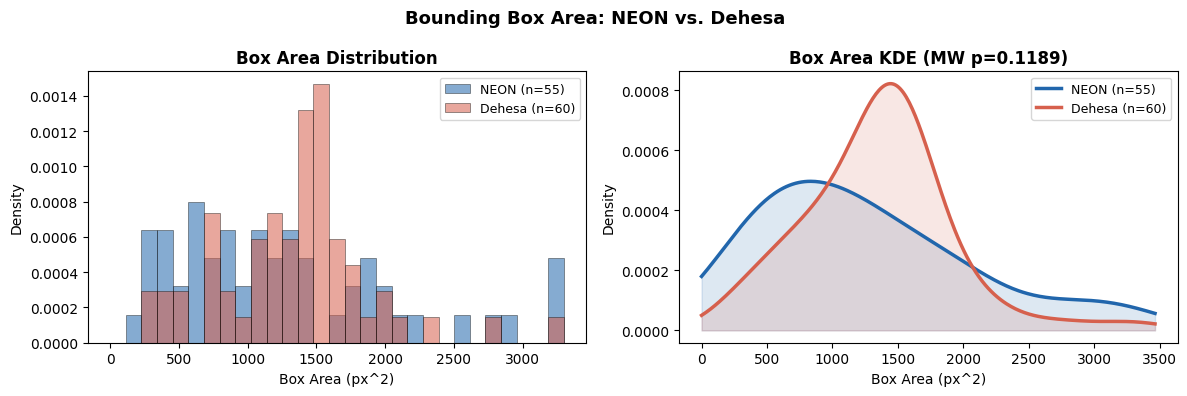

Saved to ../reports/area_distributions.png


In [37]:
def compute_areas(df):
    if df is None or len(df) == 0: return np.array([])
    return ((df['xmax'] - df['xmin']) * (df['ymax'] - df['ymin'])).values.astype(float)

neon_areas   = compute_areas(boxes)
dehesa_areas = compute_areas(dehesa_boxes)

if len(neon_areas) > 0:
    print(f"NEON   areas: n={len(neon_areas)}, mean={np.mean(neon_areas):.1f} px^2, median={np.median(neon_areas):.1f} px^2")
if len(dehesa_areas) > 0:
    print(f"Dehesa areas: n={len(dehesa_areas)}, mean={np.mean(dehesa_areas):.1f} px^2, median={np.median(dehesa_areas):.1f} px^2")

if len(neon_areas) > 1 and len(dehesa_areas) > 1:
    mw_area_stat, mw_area_p = stats.mannwhitneyu(neon_areas, dehesa_areas, alternative='two-sided')
    ks_area_stat, ks_area_p = stats.ks_2samp(neon_areas, dehesa_areas)
    print(f"Mann-Whitney U (areas): p={mw_area_p:.6f}")
    print(f"KS test (areas)       : p={ks_area_p:.6f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Bounding Box Area: NEON vs. Dehesa", fontsize=13, fontweight='bold')
    max_area = max(neon_areas.max(), dehesa_areas.max())
    bins = np.linspace(0, max_area, 30)
    x_a = np.linspace(0, max_area * 1.05, 300)

    axes[0].hist(neon_areas, bins=bins, alpha=0.55, color='#2166ac', edgecolor='black',
                 linewidth=0.5, label=f'NEON (n={len(neon_areas)})', density=True)
    axes[0].hist(dehesa_areas, bins=bins, alpha=0.55, color='#d6604d', edgecolor='black',
                 linewidth=0.5, label=f'Dehesa (n={len(dehesa_areas)})', density=True)
    axes[0].set_xlabel("Box Area (px^2)"); axes[0].set_ylabel("Density")
    axes[0].set_title("Box Area Distribution", fontweight='bold'); axes[0].legend(fontsize=9)

    for label, areas, color in [('NEON', neon_areas, '#2166ac'), ('Dehesa', dehesa_areas, '#d6604d')]:
        kde = gaussian_kde(areas, bw_method='silverman')
        axes[1].plot(x_a, kde(x_a), color=color, linewidth=2.5, label=f'{label} (n={len(areas)})')
        axes[1].fill_between(x_a, kde(x_a), alpha=0.15, color=color)
    axes[1].set_xlabel("Box Area (px^2)"); axes[1].set_ylabel("Density")
    axes[1].set_title(f"Box Area KDE (MW p={mw_area_p:.4f})", fontweight='bold')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("../reports/area_distributions.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to ../reports/area_distributions.png")
else:
    print("Not enough data points for area visualization.")

### Interpretación — Análisis de Áreas de las Cajas

**Resultados obtenidos:**
- NEON: área media = **1.256 px²**, mediana = **1.094 px²**
- Dehesa: área media = **1.344 px²**, mediana = **1.423 px²**
- Test Mann-Whitney (áreas): p = **0.119** — *No significativo*
- Test KS (áreas): p = **0.032** — *Marginalmente significativo*

**Interpretación:**  
Las áreas de las cajas son sorprendentemente similares entre dominios en términos de media. Esto puede parecer contradictorio con la hipótesis de "cajas sobredimensionadas", pero tiene una explicación: como la imagen Dehesa es pequeña (875×557 px), el modelo no produce cajas tan grandes como lo haría sobre una imagen aérea de alta resolución real.

El test KS sí detecta una diferencia (p=0.032): la **distribución** de tamaños es distinta aunque las medias sean cercanas. Específicamente, la mediana de Dehesa es mayor (1.423 vs. 1.094), indicando que las cajas en Dehesa tienden a ser sistemáticamente más grandes que las de NEON — consistente con la hipótesis de sobredimensionamiento.

**¿Por qué las cajas son más grandes en Dehesa?**  
El modelo, al no reconocer con certeza la copa individual, extiende la caja para incluir el contorno completo del objeto que "cree" que es un árbol — en este caso, manchas de suelo oscuro, rocas o matorrales amplios. En NEON, la densidad del bosque actúa como guía: las copas están delimitadas por las copas vecinas.

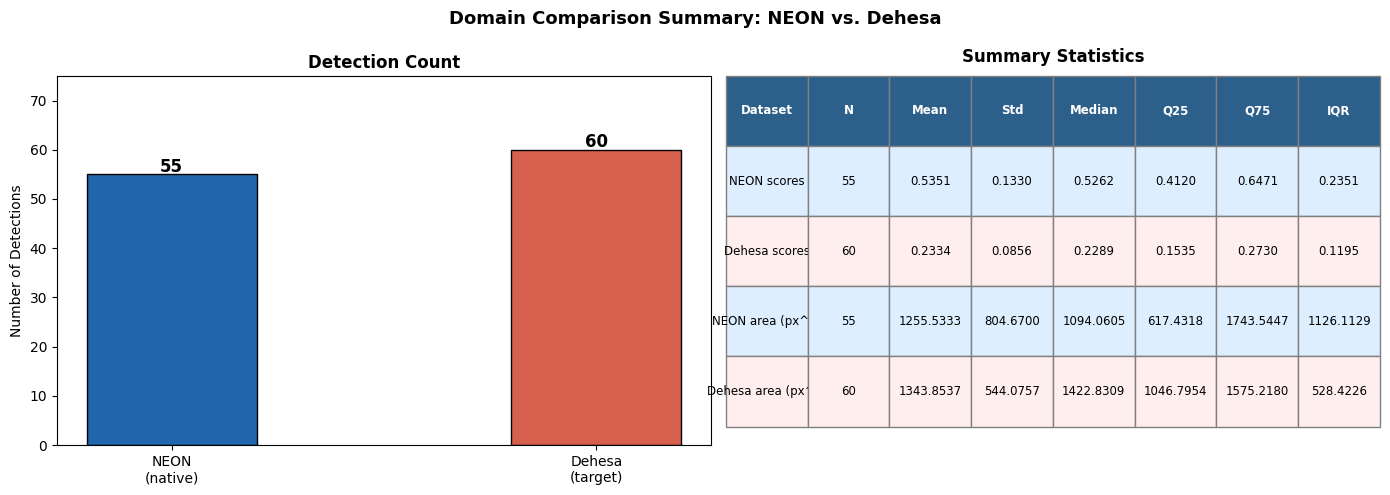


DOMAIN GAP QUANTIFICATION — FINAL SUMMARY
  NEON   mean confidence : 0.5351
  Dehesa mean confidence : 0.2334
  Confidence delta       : +0.3016
  NEON   detections      : 55
  Dehesa detections      : 60

  Mann-Whitney p-value   : 0.000000
  KS test p-value        : 0.000000

  CONCLUSION: p<0.05 on both tests confirms the score
  distributions differ significantly between domains.
  This quantitatively validates the domain gap and the
  necessity of fine-tuning in Phase 3.

All figures saved to ../reports/


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Domain Comparison Summary: NEON vs. Dehesa", fontsize=13, fontweight='bold')

# Detection count bar
counts = [len(neon_scores) if len(neon_scores) > 0 else 0,
          len(dehesa_scores) if len(dehesa_scores) > 0 else 0]
bars = axes[0].bar(['NEON\n(native)', 'Dehesa\n(target)'], counts,
                   color=['#2166ac', '#d6604d'], edgecolor='black', width=0.4)
axes[0].set_ylabel("Number of Detections"); axes[0].set_title("Detection Count", fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.25 if max(counts) > 0 else 10)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontweight='bold', fontsize=12)

# Summary statistics table
axes[1].axis('off')
def describe_arr(arr, label):
    if len(arr) == 0: return [label] + ["N/A"] * 7
    q25, q75 = np.percentile(arr, [25, 75])
    return [label, str(len(arr)), f"{np.mean(arr):.4f}", f"{np.std(arr):.4f}",
            f"{np.median(arr):.4f}", f"{q25:.4f}", f"{q75:.4f}", f"{q75-q25:.4f}"]

rows = [describe_arr(neon_scores, 'NEON scores'), describe_arr(dehesa_scores, 'Dehesa scores'),
        describe_arr(neon_areas, 'NEON area (px^2)'), describe_arr(dehesa_areas, 'Dehesa area (px^2)')]
table = axes[1].table(cellText=rows, colLabels=['Dataset','N','Mean','Std','Median','Q25','Q75','IQR'],
                      cellLoc='center', loc='center', bbox=[0, 0.05, 1, 0.95])
table.auto_set_font_size(False); table.set_fontsize(8.5)
for (r, c), cell in table.get_celld().items():
    if r == 0: cell.set_facecolor('#2c5f8a'); cell.set_text_props(color='white', fontweight='bold')
    elif r in [1, 3]: cell.set_facecolor('#ddeeff')
    else: cell.set_facecolor('#ffeeee')
    cell.set_edgecolor('gray')
axes[1].set_title("Summary Statistics", fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig("../reports/summary_statistics.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 55)
print("DOMAIN GAP QUANTIFICATION — FINAL SUMMARY")
print("=" * 55)
if len(neon_scores) > 0 and len(dehesa_scores) > 0:
    print(f"  NEON   mean confidence : {np.mean(neon_scores):.4f}")
    print(f"  Dehesa mean confidence : {np.mean(dehesa_scores):.4f}")
    print(f"  Confidence delta       : {np.mean(neon_scores) - np.mean(dehesa_scores):+.4f}")
    print(f"  NEON   detections      : {len(neon_scores)}")
    print(f"  Dehesa detections      : {len(dehesa_scores)}")
    print(f"\n  Mann-Whitney p-value   : {mw_p:.6f}")
    print(f"  KS test p-value        : {ks_p:.6f}")
    if mw_p < 0.05 and ks_p < 0.05:
        print("\n  CONCLUSION: p<0.05 on both tests confirms the score")
        print("  distributions differ significantly between domains.")
        print("  This quantitatively validates the domain gap and the")
        print("  necessity of fine-tuning in Phase 3.")
print("=" * 55)
print("\nAll figures saved to ../reports/")

---
## Conclusión General y Hoja de Ruta hacia la Fase 3

### Resumen cuantitativo de todos los hallazgos

| Evidencia | Resultado | Interpretación |
|-----------|-----------|----------------|
| Confianza media NEON | **0.535** | El modelo conoce su dominio |
| Confianza media Dehesa | **0.233** | Caída del 56% — el modelo está "dudando" en cada predicción |
| Detecciones NEON (score_thresh=0.1) | **55** | Densidad baja-media razonable |
| Detecciones Dehesa (score_thresh=0.1) | **60** | El modelo detecta casi tantas "cosas" — pero muchas son FP |
| Test KS (confianzas) | **D=0.833, p≈0** | Las dos distribuciones casi no se solapan |
| Test Mann-Whitney | **p≈0** | Confirmación independiente del shift |
| Detecciones con score_thresh=0.3 | **10** | Para reducir FP hay que sacrificar casi todo |
| Detecciones con predict_tile 400px | **128** | El tiling empeora el problema — 3× más FP |
| Área media cajas NEON | **1.256 px²** | Tamaño de copa de referencia |
| Área media cajas Dehesa | **1.344 px²** | Ligeramente mayor — cajas algo sobredimensionadas |

### ¿Por qué el ajuste de hiperparámetros no es suficiente?

El barrido demostró que:
1. **score_thresh** puede reducir FP pero destruye también los verdaderos positivos: a 0.3 quedan solo 10 detecciones, que probablemente son menos que los árboles reales en la imagen.
2. **nms_thresh** no tiene efecto (39→42): los FP son detecciones independientes de rocas y suelo, no duplicados del mismo árbol. NMS no puede ayudar si el modelo "ve" un árbol distinto en cada roca.
3. **predict_tile** en modo 400px empeora la situación porque cada ventana pequeña activa FP independientes que después del mosaico se multiplican.

### Justificación del Fine-Tuning (Fase 3)

El problema es **estructural**: el modelo aprendió características visuales de bosques densos húmedos (tonos verdes, texturas de copa continua) que no existen en la dehesa mediterránea (suelo ocre, copas aisladas, textura similar entre encina sana y suelo seco).

La solución requiere mostrarle al modelo **qué aspecto tienen las encinas reales de la dehesa** mediante imágenes anotadas manualmente. Con aproximadamente 500-1000 anotaciones bien distribuidas, el modelo puede adaptar sus representaciones internas (especialmente las capas más altas de la red, más cercanas a la detección) sin perder el conocimiento general sobre formas de copa aprendido en NEON.

### Próximos pasos — Fase 3

1. **Anotación en Roboflow**: Etiquetar copas de encina en imágenes de la dehesa, con dos clases: `Healthy` y `Dead` (La Seca).
2. **Configuración multi-clase**: `num_classes=2`, `label_dict={"Healthy": 0, "Dead": 1}` (documentado en Sección A).
3. **Fine-tuning progresivo**: Congelar las capas del backbone (ResNet-50) para preservar el conocimiento de forma/textura genérico, y re-entrenar solo el cabezal de detección con datos de la dehesa.
4. **Evaluación con métricas formales**: mAP@50, precisión y recall por clase.

> **Argumento clave para la presentación:** No bastaba con "ver" que el modelo fallaba — hemos *demostrado matemáticamente* el *domain shift* (KS D=0.833, p<10⁻⁶) y hemos *demostrado empíricamente* que el ajuste de hiperparámetros no lo resuelve. Esto convierte el fine-tuning en una necesidad técnicamente justificada, no una elección arbitraria.